# Notebook 3 — Data Exploration and Gold Signal Prototype

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [7]:
prices_clean = pd.read_parquet("clean_yfinance.parquet")

## Convert prices into modelling variables

This cell converts the cleaned price levels into variables suitable for statistical analysis.

For Gold, Brent, and DXY, we use **log returns** because these are price-like assets. Log returns are commonly used because they are additive over time and easier to compare across assets.

For VIX and US10Y, we use **level changes** instead of log returns. VIX is already an index of volatility/fear, and interest rates are naturally interpreted in percentage-point changes rather than percentage returns.

The output is `market_data`, the main working dataset used for the rest of the notebook.


In [8]:
# Log returns for price-like assets
returns = np.log(prices_clean / prices_clean.shift(1))

# Level changes for VIX and US10Y
changes = prices_clean[["VIX", "US10Y"]].diff()

# Combine into one modelling dataset
market_data = pd.DataFrame(index=prices_clean.index)

market_data["Gold_ret"] = returns["Gold"]
market_data["Brent_ret"] = returns["Brent"]
market_data["DXY_ret"] = returns["DXY"]

market_data["VIX_chg"] = changes["VIX"]
market_data["US10Y_chg"] = changes["US10Y"]

market_data = market_data.dropna()

market_data.head()

,Gold_ret,Brent_ret,DXY_ret,VIX_chg,US10Y_chg
Date,,,,,
2010-01-05,0.000358,0.005849,0.001160,-0.690001,-0.0086
2010-01-06,0.015795,0.016002,-0.001676,-0.190001,0.0053
2010-01-07,-0.002468,-0.004651,0.005405,-0.100000,0.0014
2010-01-08,0.004491,-0.001719,-0.005664,-0.930000,-0.0014
2010-01-11,0.010922,-0.004928,-0.006085,-0.580000,0.0010


## Summary statistics for returns and changes

This cell gives a first statistical profile of the variables.

The purpose is to understand whether the series are well-behaved or dominated by extreme observations. In financial data, returns often have skewness and high kurtosis, meaning they may have asymmetric behaviour and fat tails.

This matters for our project because fat-tailed returns support the need for stress testing and VaR analysis rather than relying only on normal-market assumptions.


In [12]:
return_cols = ["Gold_ret", "Brent_ret", "DXY_ret", "VIX_chg", "US10Y_chg"]

return_summary = market_data[return_cols].agg([
    "mean", 
    "std", 
    "min", 
    "max", 
    "skew"
]).T

return_summary["kurtosis"] = market_data[return_cols].kurtosis()

return_summary

,mean,std,min,max,skew,kurtosis
Gold_ret,0.000342,0.010721,-0.120657,0.059054,-0.847242,8.808881
Brent_ret,0.000031,0.023132,-0.279761,0.190774,-1.002417,15.518944
DXY_ret,0.000059,0.004453,-0.023988,0.020320,-0.037388,1.527841
VIX_chg,-0.001143,1.866759,-18.710003,24.860001,1.878807,28.854207
US10Y_chg,0.000015,0.005351,-0.032200,0.026900,0.021968,1.790663


## Return distribution plots

These histograms visualise how the return distributions look.

We are checking whether Gold, Brent, and DXY returns look roughly normal or whether they have fat tails and extreme observations. This is useful because the project is ultimately about identifying abnormal market behaviour.

If Brent has more extreme tails than Gold or DXY, it reinforces why Brent is an appropriate target commodity for stress and VaR analysis.


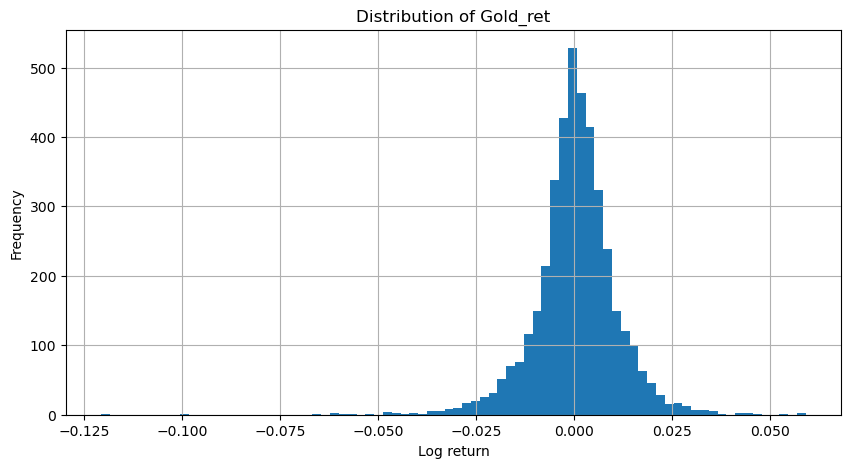

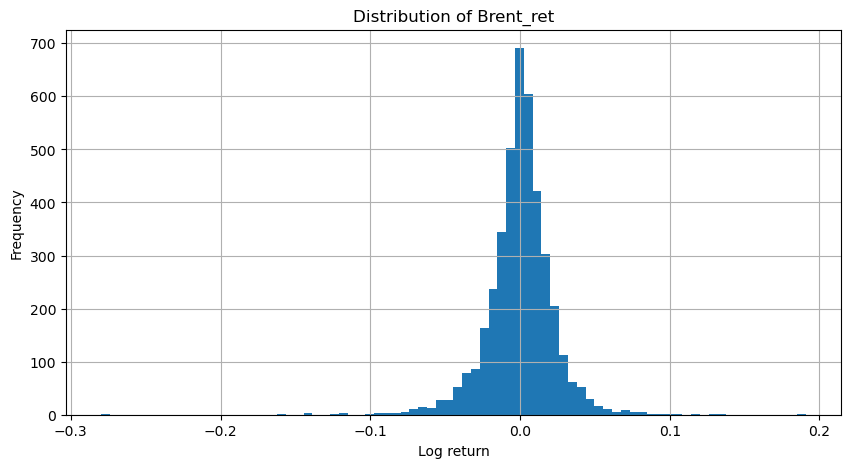

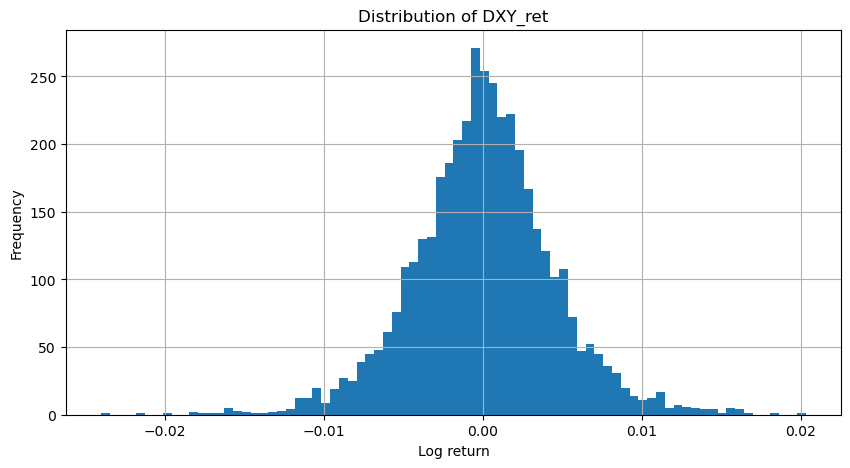

In [15]:
for col in ["Gold_ret", "Brent_ret", "DXY_ret"]:
    plt.figure(figsize=(10, 5))
    plt.hist(market_data[col].dropna(), bins=80)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Log return")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

## Worst return days

This cell lists the worst 10 daily observations for each return series.

This is a sanity check. We want to see whether the data captures known market stress days and whether the extreme observations are plausible rather than data errors.

It also helps us understand which asset has the most severe downside moves. This is especially relevant for Brent because the later notebook will define stress events and VaR exceedances using Brent returns.


In [16]:
for col in ["Gold_ret", "Brent_ret", "DXY_ret"]:
    print(f"\nWorst 10 days for {col}:")
    display(market_data[col].sort_values().head(10))


Worst 10 days for Gold_ret:


Date
2026-01-30   -0.120657
2013-04-15   -0.098206
2013-06-20   -0.065976
2026-03-19   -0.060963
2011-09-23   -0.060255
2025-10-21   -0.059062
2011-08-24   -0.057706
2020-11-09   -0.051069
2020-03-13   -0.047416
2020-02-28   -0.047386
Name: Gold_ret, dtype: float64


Worst 10 days for Brent_ret:


Date
2020-04-21   -0.279761
2020-03-09   -0.275751
2026-04-01   -0.156943
2020-03-18   -0.143878
2026-04-08   -0.142580
2022-03-09   -0.141083
2021-11-26   -0.123147
2026-03-10   -0.119654
2020-03-16   -0.119076
2026-03-23   -0.115624
Name: Brent_ret, dtype: float64


Worst 10 days for DXY_ret:


Date
2015-12-03   -0.023988
2022-11-10   -0.021394
2025-04-10   -0.019925
2022-11-04   -0.018320
2022-11-11   -0.017903
2011-10-27   -0.017608
2025-04-03   -0.016903
2020-03-26   -0.016262
2015-08-24   -0.016159
2016-06-03   -0.016140
Name: DXY_ret, dtype: float64

## Realised volatility

The next section converts daily returns into rolling realised volatility. This helps identify periods when Gold or Brent became materially more volatile. Stress periods usually show up as volatility spikes.

### 20-day versus 30-day realised volatility

We compare two rolling windows. The 20-day window is roughly one trading month and reacts faster; the 30-day window is smoother and acts as a robustness check.

## Set annualisation assumption

This cell sets `trading_days = 252`, the standard approximation for the number of trading days in a year.

We use this to annualise realised volatility. For example, a 20-day rolling standard deviation of daily returns is converted into an annualised volatility by multiplying by the square root of 252.


In [19]:
trading_days = 252

## Compute 20-day and 30-day realised volatility

This cell creates rolling realised volatility measures for Gold and Brent.

The 20-day window is roughly one trading month, so it reacts relatively quickly to stress. The 30-day window is smoother but reacts slightly later.

For this project, 20-day volatility is the better main indicator because we are interested in early warning. The 30-day version is useful as a robustness comparison.


In [22]:
for asset in ["Gold", "Brent"]:
    market_data[f"{asset}_vol_20d"] = (
        market_data[f"{asset}_ret"]
        .rolling(20)
        .std()
        * np.sqrt(trading_days)
    )

    market_data[f"{asset}_vol_30d"] = (
        market_data[f"{asset}_ret"]
        .rolling(30)
        .std()
        * np.sqrt(trading_days)
    )

market_data[[
    "Gold_vol_20d", 
    "Gold_vol_30d", 
    "Brent_vol_20d", 
    "Brent_vol_30d"
]].tail()

,Gold_vol_20d,Gold_vol_30d,Brent_vol_20d,Brent_vol_30d
Date,,,,
2026-05-25,0.199842,0.195063,0.609618,0.647434
2026-05-26,0.190646,0.186807,0.612239,0.642579
2026-05-27,0.191810,0.188672,0.585486,0.662927
2026-05-28,0.188157,0.193044,0.579066,0.648457
2026-05-29,0.203168,0.197993,0.561294,0.591468


## Plot 20-day versus 30-day realised volatility

These plots compare the short and slightly longer volatility windows.

The purpose is to visually identify stress periods. If the 20-day volatility spikes earlier or more sharply than the 30-day volatility, that supports using 20-day volatility as the main stress indicator.

This also helps the group explain why the chosen rolling window is not arbitrary.


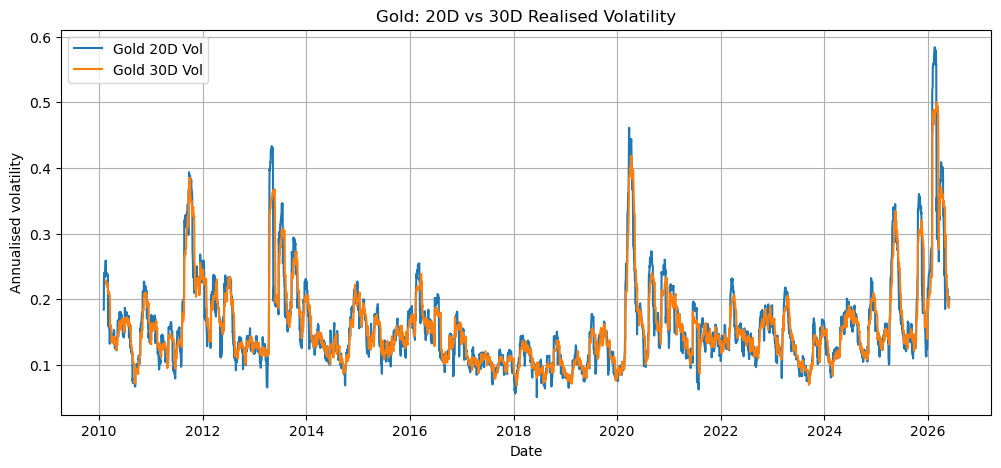

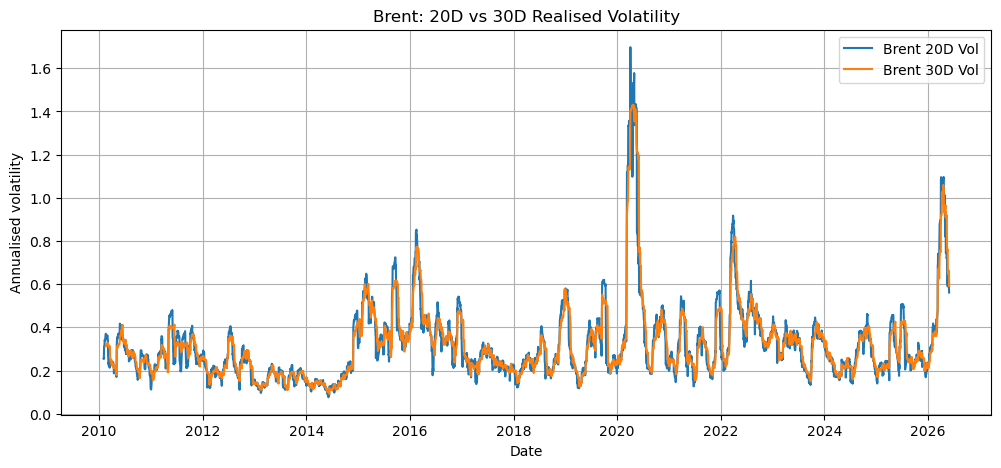

In [23]:
for asset in ["Gold", "Brent"]:
    plt.figure(figsize=(12, 5))
    plt.plot(market_data.index, market_data[f"{asset}_vol_20d"], label=f"{asset} 20D Vol")
    plt.plot(market_data.index, market_data[f"{asset}_vol_30d"], label=f"{asset} 30D Vol")
    plt.title(f"{asset}: 20D vs 30D Realised Volatility")
    plt.xlabel("Date")
    plt.ylabel("Annualised volatility")
    plt.legend()
    plt.grid(True)
    plt.show()

## Create trailing z-scores for gold returns and gold volatility

This cell defines a helper function, `trailing_zscore()`, and applies it to Gold return and Gold realised volatility.

A trailing z-score measures how unusual today’s value is compared with its own past history. The `.shift(1)` is important because it ensures the benchmark is based only on information available before today, reducing look-ahead bias.

`Gold_ret_z` asks: is today’s gold return unusually large?

`Gold_vol_z` asks: is gold volatility unusually high?

These are the first two building blocks of the gold alarm signal.


In [39]:
z_window = 252  # roughly 1 trading year

def trailing_zscore(series, window=252):
    rolling_mean = series.rolling(window).mean().shift(1)
    rolling_std = series.rolling(window).std().shift(1)
    return (series - rolling_mean) / rolling_std

market_data["Gold_ret_z"] = trailing_zscore(
    market_data["Gold_ret"], 
    window=z_window
)

market_data["Gold_vol_z"] = trailing_zscore(
    market_data["Gold_vol_20d"], 
    window=z_window
)

market_data[["Gold_ret", "Gold_ret_z", "Gold_vol_20d", "Gold_vol_z"]].tail()

,Gold_ret,Gold_ret_z,Gold_vol_20d,Gold_vol_z
Date,,,,
2026-05-25,0.000000,-0.068910,0.199842,-0.377348
2026-05-26,-0.004567,-0.337088,0.190646,-0.449038
2026-05-27,-0.011824,-0.768748,0.191810,-0.436214
2026-05-28,0.011580,0.610942,0.188157,-0.462477
2026-05-29,0.020612,1.140530,0.203168,-0.337971


## Plot gold z-scores

This cell plots the Gold return z-score and Gold volatility z-score.

The horizontal lines at +2 and -2 standard deviations are preliminary alarm thresholds. A 2-standard-deviation move is uncommon enough to be noteworthy, but not so rare that it only captures extreme crisis days.

These plots help us visually inspect whether gold was abnormal during known stress periods.


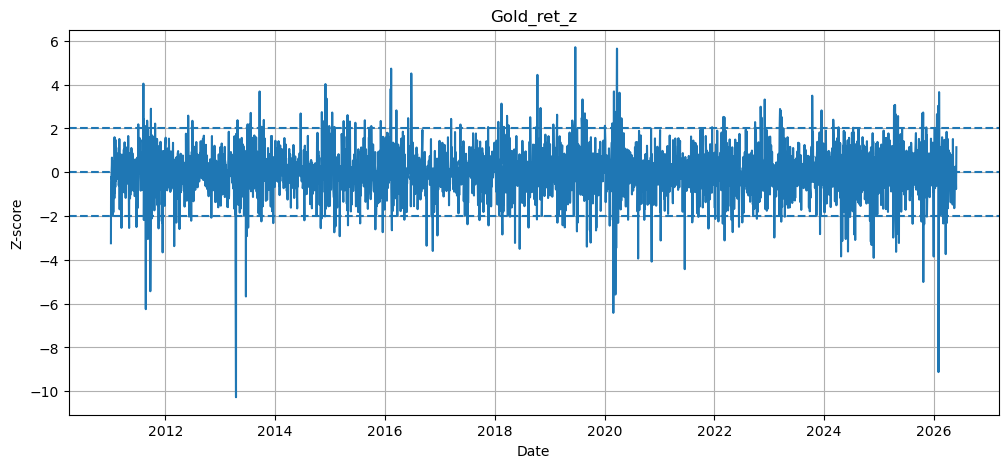

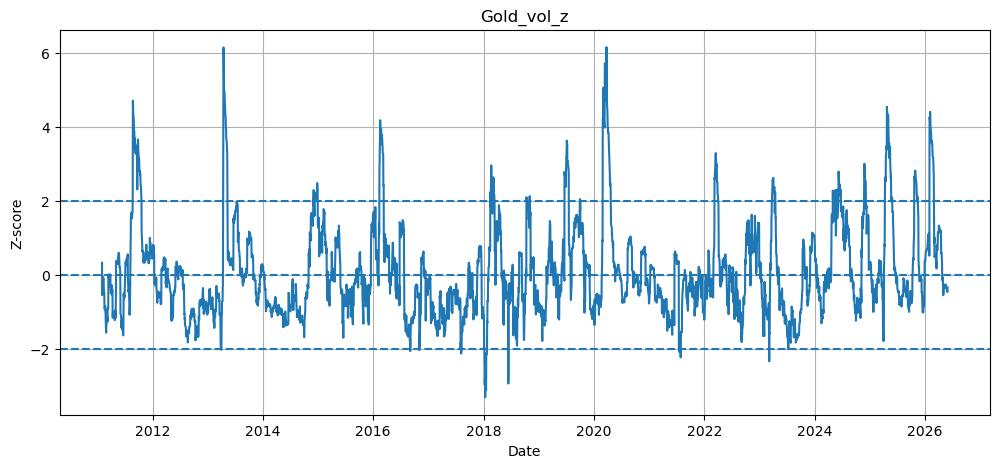

In [40]:
for col in ["Gold_ret_z", "Gold_vol_z"]:
    plt.figure(figsize=(12, 5))
    plt.plot(market_data.index, market_data[col])
    plt.axhline(2, linestyle="--")
    plt.axhline(-2, linestyle="--")
    plt.axhline(0, linestyle="--")
    plt.title(col)
    plt.xlabel("Date")
    plt.ylabel("Z-score")
    plt.grid(True)
    plt.show()

## Static correlation sanity check

The next section studies the average relationship between Gold, Brent, DXY, VIX, and US10Y.

This is a basic sanity check before building any signal. If the relationships look completely unreasonable, the data or variable definitions may need to be revisited.


## Compute static correlation matrix

This cell calculates the full-sample correlation matrix across the key variables.

We are checking whether Gold behaves differently from Brent and whether it has intuitive relationships with DXY, VIX, and yields.

This is not the final signal because correlations can change through time. It is only a broad full-sample diagnostic.


In [24]:
corr_cols = ["Gold_ret", "Brent_ret", "DXY_ret", "VIX_chg", "US10Y_chg"]

corr_matrix = market_data[corr_cols].corr()

corr_matrix

,Gold_ret,Brent_ret,DXY_ret,VIX_chg,US10Y_chg
Gold_ret,1.000000,0.099472,-0.356413,-0.014664,-0.225566
Brent_ret,0.099472,1.000000,-0.090398,-0.240620,0.218884
DXY_ret,-0.356413,-0.090398,1.000000,0.089630,0.164480
VIX_chg,-0.014664,-0.240620,0.089630,1.000000,-0.224666
US10Y_chg,-0.225566,0.218884,0.164480,-0.224666,1.000000


## Visualise the static correlation matrix

This heatmap makes the correlation matrix easier to interpret visually.

The goal is to quickly identify which variables are positively or negatively related. In later sections, we move beyond this full-sample view and study rolling correlations because the project is about regime shifts, not just average relationships.


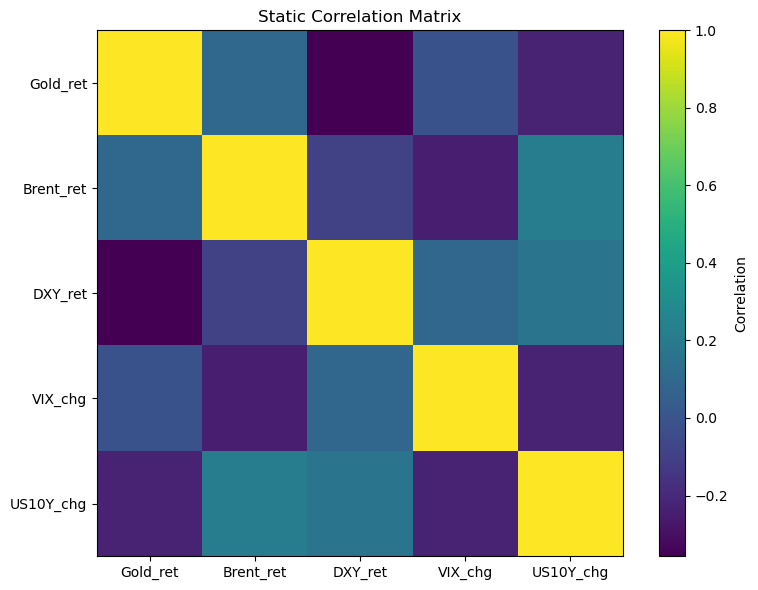

In [28]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Static Correlation Matrix")
plt.tight_layout()
plt.show()

## Regression beta sanity check

This cell estimates a simple regression of Gold returns against Brent returns, DXY returns, VIX changes, and US10Y changes.

The purpose is to understand Gold’s normal relationship with the other market variables. The coefficients are not meant to be a final predictive model. They are a sanity check and a way to estimate what Gold would normally do given movements in Brent, the dollar, risk sentiment, and yields.

This regression also gives us residuals, which are useful because an unusually large residual means Gold moved differently from what the model would have expected.


In [31]:
reg_data = market_data[[
    "Gold_ret", 
    "Brent_ret", 
    "DXY_ret", 
    "VIX_chg", 
    "US10Y_chg"
]].dropna()

y = reg_data["Gold_ret"]
X = reg_data[["Brent_ret", "DXY_ret", "VIX_chg", "US10Y_chg"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Gold_ret   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     208.3
Date:                Mon, 01 Jun 2026   Prob (F-statistic):          5.56e-163
Time:                        00:45:21   Log-Likelihood:                 13255.
No. Observations:                4131   AIC:                        -2.650e+04
Df Residuals:                    4126   BIC:                        -2.647e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      2.567      0.0

## Create gold regression residual z-score

This cell stores the residuals from the regression and converts them into a trailing z-score.

The residual captures the part of Gold’s return that is not explained by Brent, DXY, VIX, and US10Y in the regression.

`Gold_residual_z` therefore asks: is Gold behaving abnormally even after controlling for these other market variables?

This is a stronger abnormality measure than a simple return z-score because it accounts for the broader market environment.


In [42]:
market_data.loc[reg_data.index, "Gold_residual"] = model.resid

market_data["Gold_residual_z"] = trailing_zscore(
    market_data["Gold_residual"],
    window=z_window
)

market_data[["Gold_residual", "Gold_residual_z"]].tail()

,Gold_residual,Gold_residual_z
Date,,
2026-05-25,-0.000393,-0.066477
2026-05-26,-0.006631,-0.446757
2026-05-27,-0.009526,-0.627120
2026-05-28,0.009016,0.507047
2026-05-29,0.020774,1.221593


## Plot gold residual z-score

This plot shows when Gold behaved unusually relative to the regression-implied relationship.

Large positive or negative values indicate days when Gold moved much more than expected after accounting for Brent, DXY, VIX, and US10Y.

This can be used as one component of the gold alarm signal.


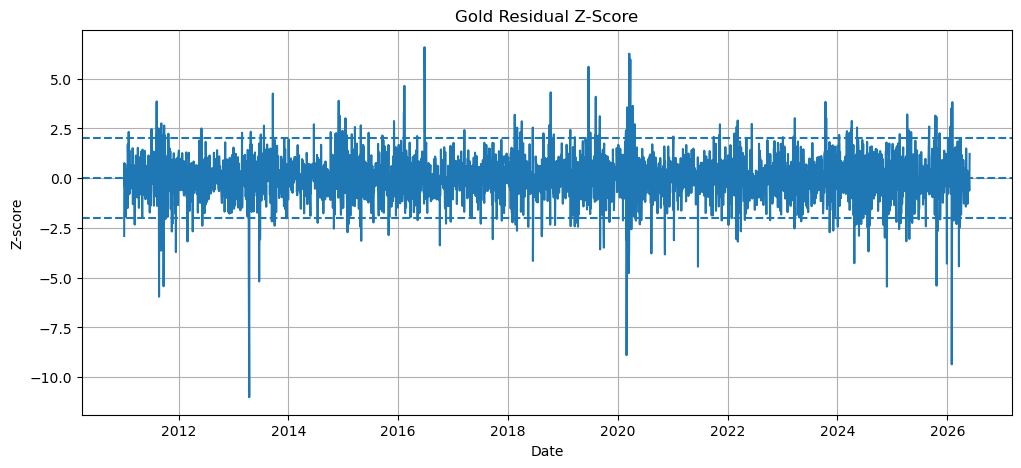

In [43]:
plt.figure(figsize=(12, 5))
plt.plot(market_data.index, market_data["Gold_residual_z"])
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0, linestyle="--")
plt.title("Gold Residual Z-Score")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.grid(True)
plt.show()

## Compute 60-day rolling correlations

This cell computes rolling correlations between Gold returns and four other variables: Brent returns, DXY returns, VIX changes, and US10Y changes.

We use rolling correlations because the relationship between Gold and other markets is not constant. During stress periods, Gold may behave more like a safe-haven asset; during liquidation periods, it may move together with other assets.

A 60-day window is a practical compromise: it is long enough to reduce daily noise, but short enough to capture regime changes.


In [32]:
corr_window = 60

market_data["Gold_Brent_corr_60d"] = (
    market_data["Gold_ret"]
    .rolling(corr_window)
    .corr(market_data["Brent_ret"])
)

market_data["Gold_DXY_corr_60d"] = (
    market_data["Gold_ret"]
    .rolling(corr_window)
    .corr(market_data["DXY_ret"])
)

market_data["Gold_VIX_corr_60d"] = (
    market_data["Gold_ret"]
    .rolling(corr_window)
    .corr(market_data["VIX_chg"])
)

market_data["Gold_US10Y_corr_60d"] = (
    market_data["Gold_ret"]
    .rolling(corr_window)
    .corr(market_data["US10Y_chg"])
)

market_data[[
    "Gold_Brent_corr_60d",
    "Gold_DXY_corr_60d",
    "Gold_VIX_corr_60d",
    "Gold_US10Y_corr_60d"
]].tail()

,Gold_Brent_corr_60d,Gold_DXY_corr_60d,Gold_VIX_corr_60d,Gold_US10Y_corr_60d
Date,,,,
2026-05-25,-0.402927,-0.228808,-0.204416,-0.416158
2026-05-26,-0.423256,-0.265182,-0.219674,-0.439049
2026-05-27,-0.397735,-0.221346,-0.185799,-0.446718
2026-05-28,-0.397726,-0.224501,-0.184813,-0.454176
2026-05-29,-0.399164,-0.219611,-0.176891,-0.447619


## Plot 60-day rolling correlations

These plots show how Gold’s relationships with Brent, DXY, VIX, and US10Y evolve over time.

This matters because the project is about early warning and regime instability. A sudden change in Gold’s correlation with Brent, DXY, VIX, or yields may indicate that the market regime is shifting.

These plots are exploratory; the next step converts rolling correlations into z-scores so we can identify unusually large relationship changes systematically.


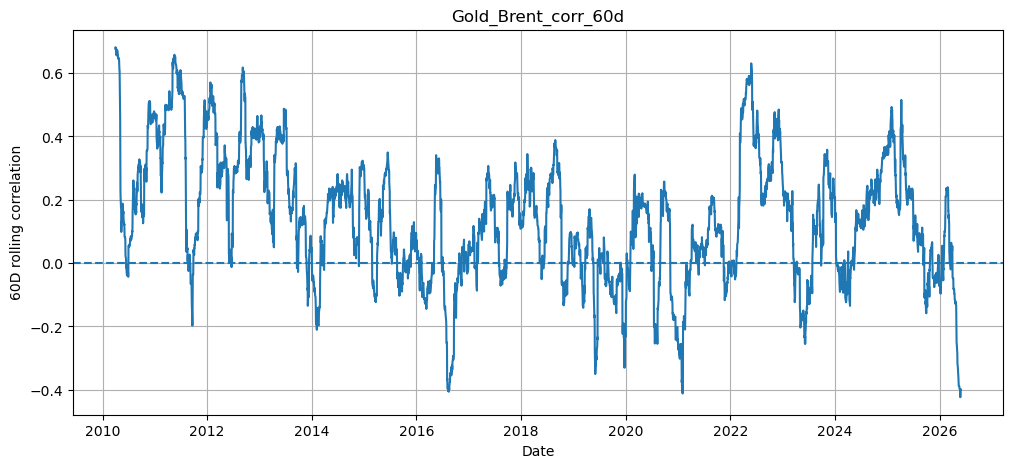

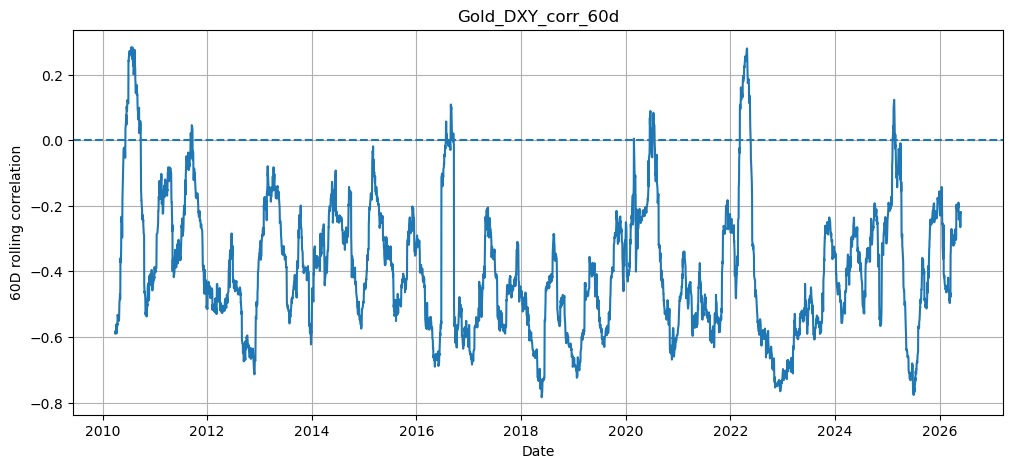

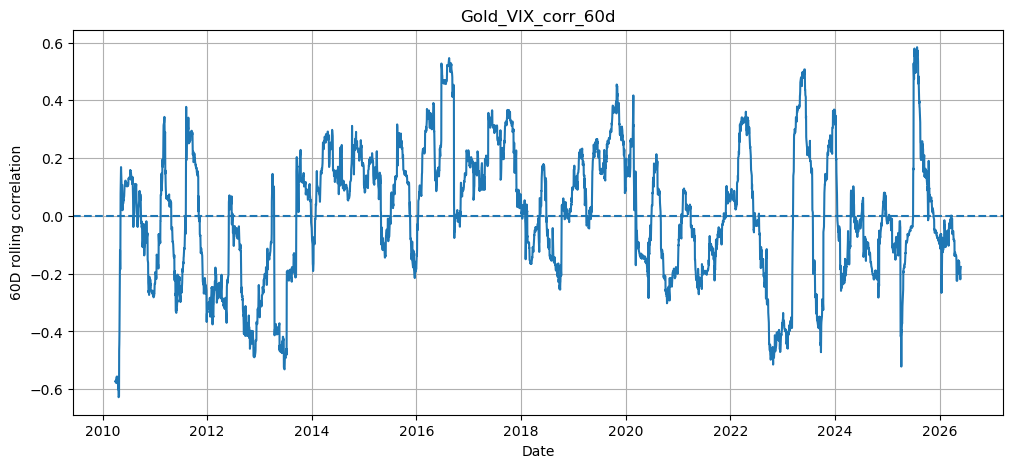

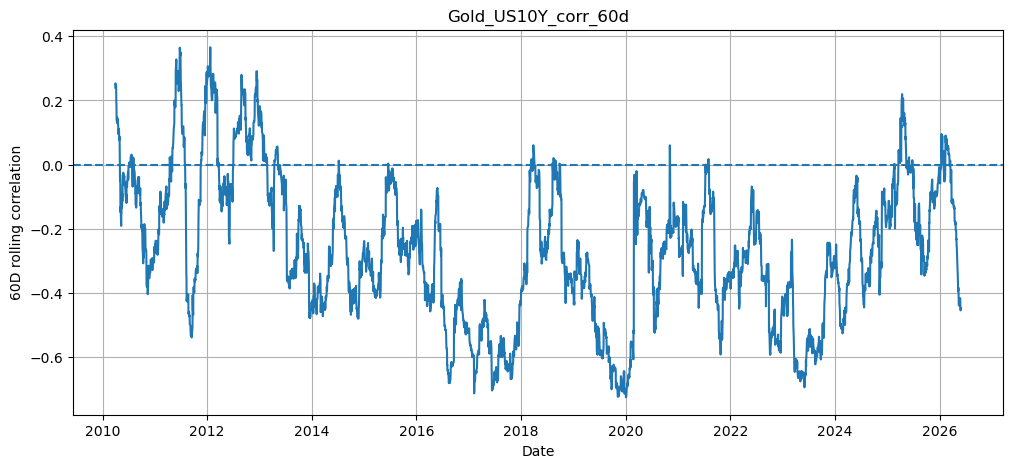

In [33]:
rolling_corr_cols = [
    "Gold_Brent_corr_60d",
    "Gold_DXY_corr_60d",
    "Gold_VIX_corr_60d",
    "Gold_US10Y_corr_60d"
]

for col in rolling_corr_cols:
    plt.figure(figsize=(12, 5))
    plt.plot(market_data.index, market_data[col])
    plt.axhline(0, linestyle="--")
    plt.title(col)
    plt.xlabel("Date")
    plt.ylabel("60D rolling correlation")
    plt.grid(True)
    plt.show()

## Reusable trailing z-score function

This cell defines the `trailing_zscore()` helper function again.

Strictly speaking, this is redundant because the same function was already defined earlier. It does not break the notebook, but for a cleaner final version, you can remove this duplicate and keep only the earlier function definition.

The function is used to compare current values against their own trailing historical distribution.


In [34]:
def trailing_zscore(series, window=252):
    rolling_mean = series.rolling(window).mean().shift(1)
    rolling_std = series.rolling(window).std().shift(1)
    return (series - rolling_mean) / rolling_std

## Create z-scores for rolling correlations

This cell converts each rolling correlation into a trailing z-score.

This tells us whether Gold’s current relationship with Brent, DXY, VIX, or US10Y is historically unusual.

For example, if the Gold-Brent rolling correlation z-score is very high or very low, it means the Gold-Brent relationship has shifted significantly compared with its own past behaviour.


In [35]:
for col in rolling_corr_cols:
    market_data[f"{col}_z"] = trailing_zscore(market_data[col], window=z_window)

corr_z_cols = [f"{col}_z" for col in rolling_corr_cols]

market_data[corr_z_cols].tail()

,Gold_Brent_corr_60d_z,Gold_DXY_corr_60d_z,Gold_VIX_corr_60d_z,Gold_US10Y_corr_60d_z
Date,,,,
2026-05-25,-2.865189,0.989363,-1.219997,-2.189477
2026-05-26,-2.951940,0.784193,-1.288277,-2.332592
2026-05-27,-2.725507,1.016315,-1.118749,-2.357095
2026-05-28,-2.681422,0.991416,-1.109598,-2.378552
2026-05-29,-2.648687,1.010622,-1.067271,-2.295572


## Plot rolling correlation z-scores

These plots show when Gold’s relationships with other variables became unusually strong or unusually weak.

The +2 and -2 lines act as preliminary thresholds for correlation breakdown or regime change.

This is important for signal creation because a gold alarm should not be based only on Gold’s own return or volatility. It can also be based on abnormal changes in Gold’s relationship with the rest of the market.


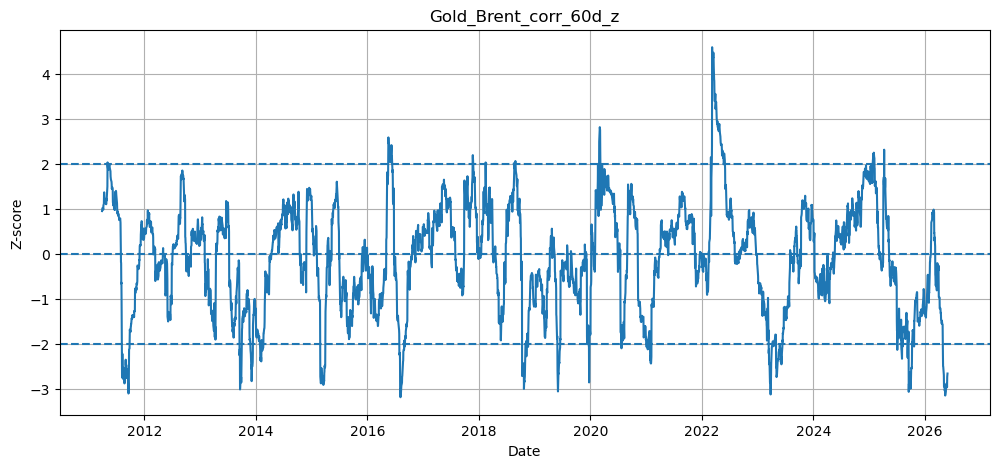

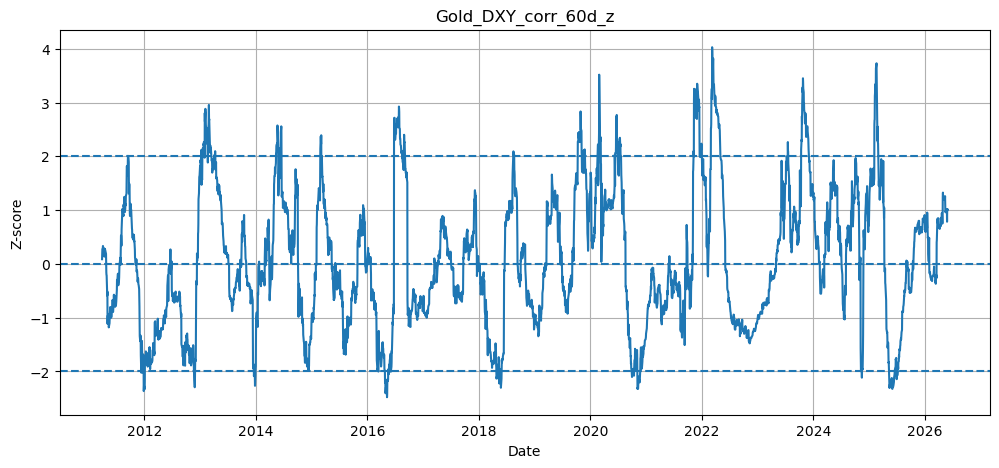

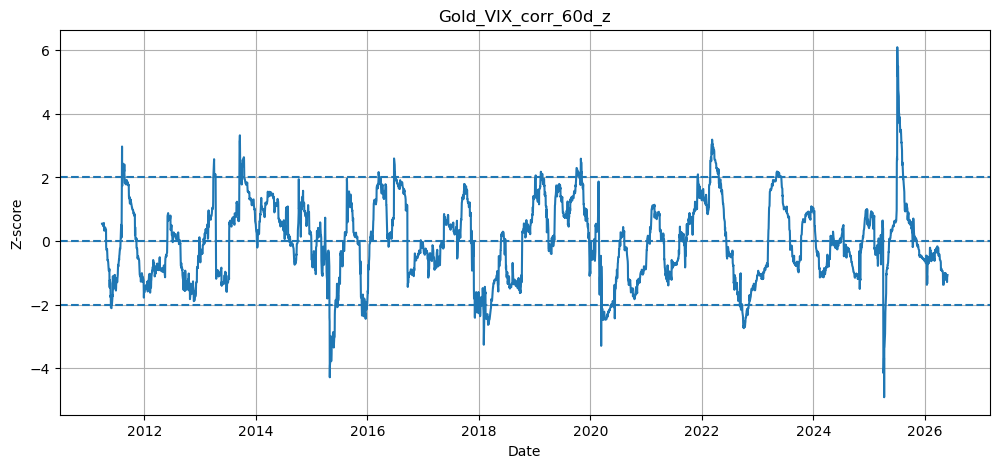

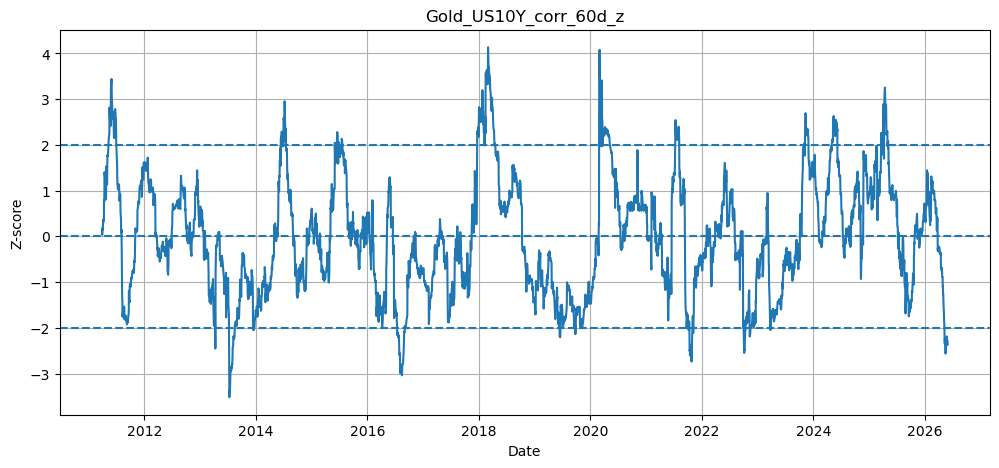

In [36]:
for col in corr_z_cols:
    plt.figure(figsize=(12, 5))
    plt.plot(market_data.index, market_data[col])
    plt.axhline(2, linestyle="--")
    plt.axhline(-2, linestyle="--")
    plt.axhline(0, linestyle="--")
    plt.title(col)
    plt.xlabel("Date")
    plt.ylabel("Z-score")
    plt.grid(True)
    plt.show()

## Gold alarm signals

This section combines the different gold abnormality measures into candidate alarm signals.

We do not rely on only one signal because Gold can become informative in different ways:

1. Gold itself moves unusually.
2. Gold volatility becomes unusually high.
3. Gold behaves unusually relative to the regression model.
4. Gold’s correlations with other variables shift abnormally.

The composite alarm tries to reduce noise by requiring more than one category of abnormality to trigger.


## Construct gold alarm versions

This cell creates several versions of the gold alarm.

`Gold_alarm_simple` triggers when Gold return or Gold volatility is abnormal.

`Gold_alarm_residual` triggers when the regression residual is abnormal.

`Gold_alarm_corr` triggers when at least one rolling correlation z-score is abnormal.

`Gold_alarm_score` counts how many of these signal groups trigger.

`Gold_alarm_composite` triggers when at least two out of the three signal groups trigger. This makes the alarm stricter and may reduce false positives.


In [44]:
# Version 1: gold return or gold volatility abnormal
market_data["Gold_alarm_simple"] = (
    (market_data["Gold_ret_z"].abs() > 2) |
    (market_data["Gold_vol_z"] > 2)
).astype(int)

# Version 2: regression residual abnormal
market_data["Gold_alarm_residual"] = (
    market_data["Gold_residual_z"].abs() > 2
).astype(int)

# Version 3: correlation relationship abnormal
market_data["Gold_alarm_corr"] = (
    market_data[corr_z_cols].abs().max(axis=1) > 2
).astype(int)

# Composite score
market_data["Gold_alarm_score"] = (
    market_data["Gold_alarm_simple"] +
    market_data["Gold_alarm_residual"] +
    market_data["Gold_alarm_corr"]
)

# Composite alarm: at least 2 out of 3 signal groups trigger
market_data["Gold_alarm_composite"] = (
    market_data["Gold_alarm_score"] >= 2
).astype(int)

market_data[[
    "Gold_alarm_simple",
    "Gold_alarm_residual",
    "Gold_alarm_corr",
    "Gold_alarm_score",
    "Gold_alarm_composite"
]].sum()

Gold_alarm_simple        470
Gold_alarm_residual      226
Gold_alarm_corr         1177
Gold_alarm_score        1873
Gold_alarm_composite     325
dtype: int64

## Threshold sensitivity analysis

This section tests whether the number of alarms changes meaningfully when the threshold is set at 1, 2, or 3 standard deviations.

This matters because the alarm threshold is a modelling choice. A 1-standard-deviation threshold may be too sensitive and create too many false alarms. A 3-standard-deviation threshold may be too strict and miss useful early warnings. A 2-standard-deviation threshold is a reasonable starting point.


## Compare 1SD, 2SD, and 3SD alarm thresholds

This cell creates gold alarms at three different z-score thresholds and summarises how often each one triggers.

The purpose is to understand signal frequency. A useful early-warning indicator should not trigger every few days, but it also should not be so rare that it only appears after the stress event has already happened.

This table helps justify the final threshold choice.


In [47]:
thresholds = [1, 2, 3]

for threshold in thresholds:
    market_data[f"Gold_alarm_{threshold}sd"] = (
        (market_data["Gold_ret_z"].abs() > threshold) |
        (market_data["Gold_vol_z"] > threshold) |
        (market_data["Gold_residual_z"].abs() > threshold) |
        (market_data[corr_z_cols].abs().max(axis=1) > threshold)
    ).astype(int)

threshold_summary = pd.DataFrame({
    "Threshold": thresholds,
    "Alarm_Count": [
        market_data[f"Gold_alarm_{threshold}sd"].sum()
        for threshold in thresholds
    ],
    "Alarm_Rate": [
        market_data[f"Gold_alarm_{threshold}sd"].mean()
        for threshold in thresholds
    ]
})

threshold_summary

,Threshold,Alarm_Count,Alarm_Rate
0,1,3435,0.831518
1,2,1471,0.356088
2,3,353,0.085451


## Event stress test

This section performs quick visual checks around selected stress periods.

The purpose is not to prove the model using hand-picked events. The full-sample lead-time test should do that later. Instead, these event windows help us visually inspect whether the gold alarm behaves sensibly during periods such as COVID, 2022, and February 2026.


## Define event-window plotting function

This cell defines a reusable function to plot Gold volatility, Brent volatility, and composite gold alarm dates for a selected event window.

This helps us visually answer: did the Gold alarm appear before or during Brent stress?

The function also checks whether the selected date range exists in the dataset. This is useful for the February 2026 window, because it will only work if the data has been downloaded far enough into 2026.


In [50]:
def plot_event_window(data, start, end, title):
    event_data = data.loc[start:end].copy()

    if event_data.empty:
        print(f"No data available for {title}")
        return

    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.plot(
        event_data.index,
        event_data["Brent_vol_20d"],
        label="Brent 20D Vol"
    )

    ax1.plot(
        event_data.index,
        event_data["Gold_vol_20d"],
        label="Gold 20D Vol"
    )

    alarm_dates = event_data.index[event_data["Gold_alarm_composite"] == 1]

    ax1.scatter(
        alarm_dates,
        event_data.loc[alarm_dates, "Brent_vol_20d"],
        marker="x",
        label="Composite Gold Alarm"
    )

    ax1.set_title(title)
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Annualised volatility")
    ax1.legend()
    ax1.grid(True)

    plt.show()

## Plot selected event windows

This cell applies the event-window plotting function to three periods:

1. COVID market shock.
2. 2022 inflation / Russia-Ukraine / energy stress.
3. February 2026 period.

These are visual case studies. They should support the narrative, but they should not replace the formal lead-time test in the next notebook.


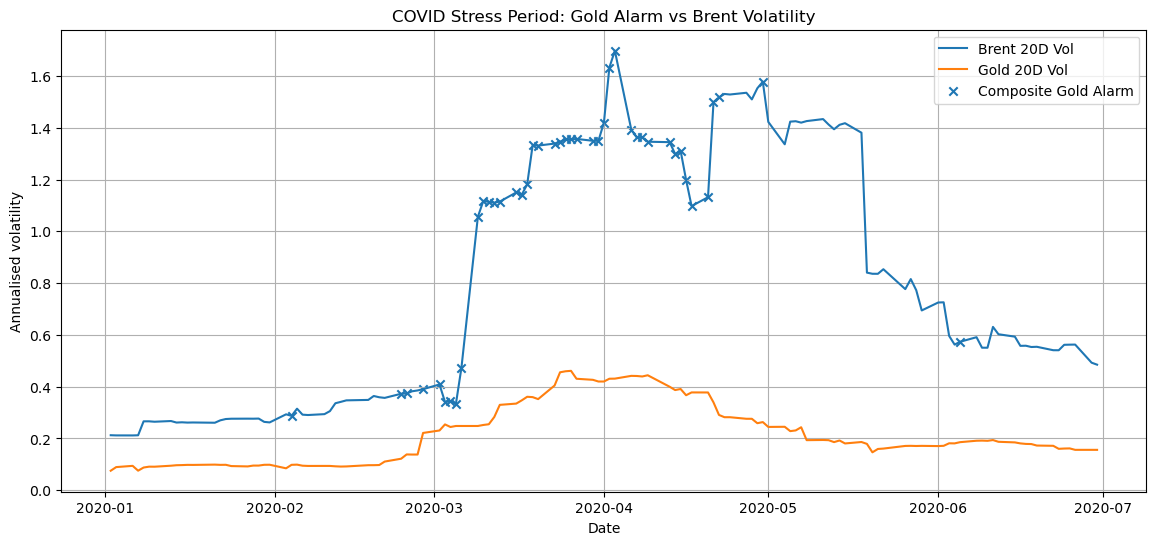

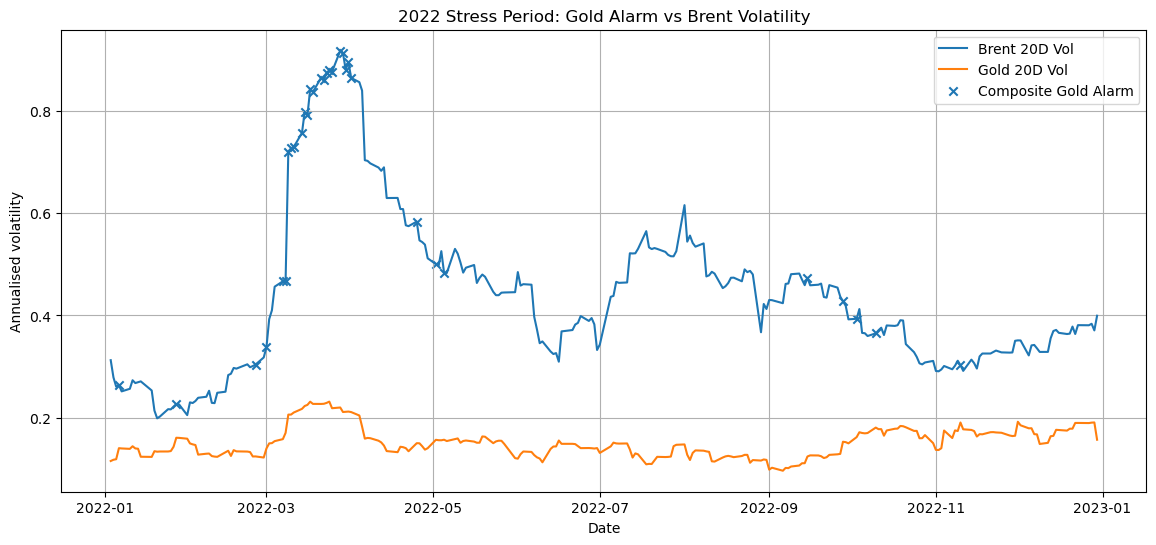

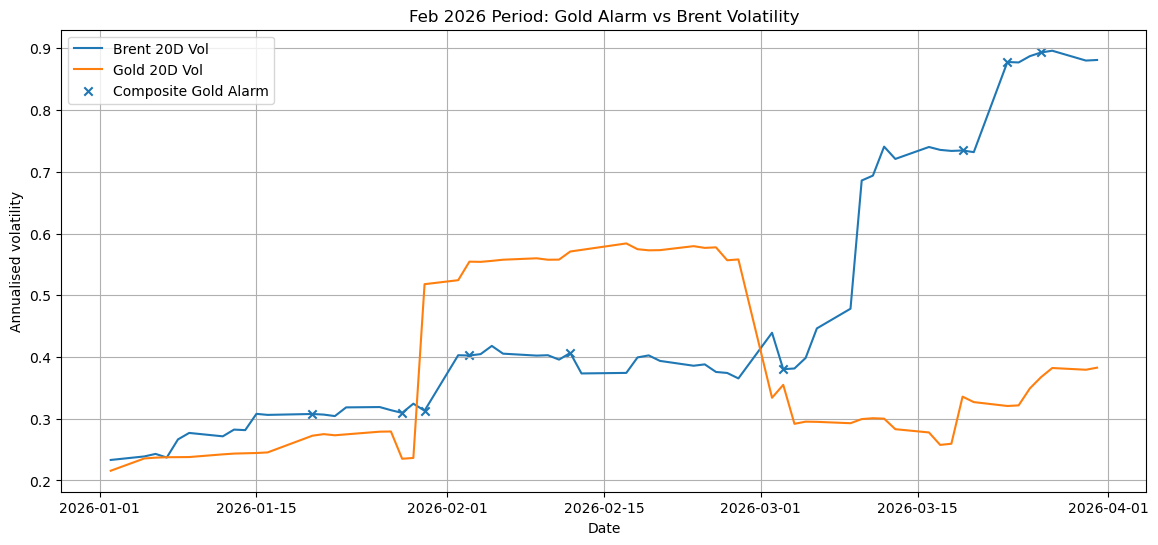

In [51]:
# COVID stress period
plot_event_window(
    market_data,
    start="2020-01-01",
    end="2020-06-30",
    title="COVID Stress Period: Gold Alarm vs Brent Volatility"
)

# 2022 inflation / Russia-Ukraine / energy stress
plot_event_window(
    market_data,
    start="2022-01-01",
    end="2022-12-31",
    title="2022 Stress Period: Gold Alarm vs Brent Volatility"
)

# Feb 2026 period
plot_event_window(
    market_data,
    start="2026-01-01",
    end="2026-03-31",
    title="Feb 2026 Period: Gold Alarm vs Brent Volatility"
)

## Save the exploration dataset

This cell saves the enriched `market_data` dataset as a Parquet file.

This is the output of Notebook 3. Notebook 4 can then load `market_data_exploration.parquet` directly and proceed to Brent stress definitions, VaR calculation, and lead-time testing.

Saving the output also keeps the workflow modular: each notebook has a clear input and output.


In [52]:
market_data.to_parquet("market_data_exploration.parquet")